# ÁNALISIS DE VENTAS 
---
### Andrea Marcial 

> Análisis de Rentabilidad- Superstore Sales
> - Análisis explorando que factores afectan la rentabilidad de una tienda retail: productos, estacionalidad y comportamiento de clientes.

**Rentabilidad por producto** → Tables y Bookcases generan pérdidas por descuentos excesivos
---
**Estacionalidad** → Fuerte pico en Nov-Dic, caída en Ene-Feb
---
**Concentración de clientes** → 40% de clientes rentables generan el 80% de ganancia; 19.5% de todos los clientes generan pérdidas
---

### REGIONES
 La región **Oeste** genera casi el triple de ganancia que la región **Central** (\\$108,418 vs \\$39,706)
 
### CATEGORÍAS
 **Furniture** genera casi igual que **Office Suplies** ( \\$742K vs \\$719K), pero su ganáncia es mínima ( \\$18K vs \\$122K).
 >Esta vendiendo mucho, pero su ganancia es mínima

### DESCUENTOS
 >A partir de un descuento de 20% en adelante, la ganancia promedio se vuelve negativa (pérdidas)

### Análisis por sub-categorías

- Tables es la subcategoría menos rentable de la tienda, generando pérdidas de \\$17,725 pese a ventas de más de \\$200K, impulsado por descuentos promedio de 26%. Sin embargo, el descuento alto no siempre implica pérdida.
- Binders sostiene rentabilidad con descuentos aún mayores (37%), sugiriendo que el problema de Tables es una combinación de descuento excesivo y margen de producto bajo.

### Tendencia de las ventas

- Las ventas muestran una clara estacionalidad, con noviembre y diciembre generando más del doble de ventas que enero y febrero, consistente con patrones de compra navideña.
- Además, se observa una tendencia de crecimiento año con año, con los picos de venta de 2017 casi duplicando los de 2014.
- Se recomienda reforzar inventario y personal en Q4, y planear promociones estratégicas para Q1 que ayuden a suavizar la caída post-navideña.

### Análisis de Clientes

- La ganancia está moderadamente concentrada: el 40% de los clientes rentables (255 de 638) generan el 80% de la ganancia total. Sin embargo, un hallazgo más urgente es que 155 de los 793 clientes (19.5%) generan pérdidas netas para el negocio.
- Se recomienda priorizar programas de retención para el segmento de alta rentabilidad, y analizar por qué ciertos clientes generan pérdidas consistentes — posiblemente vinculado a productos con descuentos excesivos como Tables.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


El archivo .csv fue guardado con una codificación de texto distinta a la que pandas usa por defecto (utf-8).
Solo le agregamos encoding='latin1' al final. Esta codificación es más flexible y suele resolver este tipo de error con archivos que vienen de Excel o de sistemas en Windows (que es probablemente de donde salió este dataset originalmente).

In [2]:
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Corrección de tipo de datos

Pasamos **Order Date** y **Ship Date** a formato *datetime*

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# Buscamos duplicados 

In [7]:
df.duplicated().sum()

np.int64(0)

# CONCLUCIÓN DE LA LIMPIEZA DEL DATASET

 Se encontro un Dataset bastante limpio, se realizaron las siguientes acciones:
 - Pasamos **Order Date** y **Ship Date** a formato *datetime*
   ```df['Order Date'] = pd.to_datetime(df['Order Date'])
   ```df['Ship Date'] = pd.to_datetime(df['Ship Date'])
   
 >No se encontraron nulos ni lineas duplicadas


# ANÁLISIS DEL NEGOCIO
---

# ¿Qué región genera más ganancia *(Profit)*?


In [8]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

# ¿Qué categoría de producto vende más pero cuál es más rentable?

In [9]:
df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit',ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728


# ¿Los descuentos están afectando la ganancia?

In [10]:
df.groupby('Discount')['Profit'].mean().sort_values()

Discount
0.50   -310.703456
0.45   -226.646464
0.40   -111.927429
0.80   -101.796797
0.70    -95.874060
0.32    -88.560656
0.30    -45.679636
0.60    -43.077212
0.20     24.702572
0.15     27.288298
0.00     66.900292
0.10     96.055074
Name: Profit, dtype: float64

## RESULTADOS DE LA PRIMER PARTE DEL ANÁLISIS

### REGIONES
 La región **Oeste** genera casi el triple de ganancia que la región **Central** (\\$108,418 vs \\$39,706)
 
### CATEGORÍAS
 **Furniture** genera casi igual que **Office Suplies** ( \\$742K vs \\$719K), pero su ganáncia es mínima ( \\$18K vs \\$122K).
 >Esta vendiendo mucho, pero su ganancia es mínima

### DESCUENTOS
 >A partir de un descuento de 20% en adelante, la ganancia promedio se vuelve negativa (pérdidas)


#### Vamos a confirmar la relación entre Furniture y los descuentos altos. 

In [11]:
df.groupby('Category')['Discount'].mean().sort_values(ascending=False)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

In [12]:
df.groupby('Sub-Category')[['Sales', 'Profit', 'Discount']].agg({
    'Sales': 'sum',
    'Profit':'sum',
    'Discount':'mean'
}).sort_values('Profit')

,Sales,Profit,Discount
Sub-Category,,,
Tables,206965.5320,-17725.4811,0.261285
Bookcases,114879.9963,-3472.5560,0.211140
Supplies,46673.5380,-1189.0995,0.076842
Fasteners,3024.2800,949.5182,0.082028
Machines,189238.6310,3384.7569,0.306087
Labels,12486.3120,5546.2540,0.068681
Art,27118.7920,6527.7870,0.074874
Envelopes,16476.4020,6964.1767,0.080315
Furnishings,91705.1640,13059.1436,0.138349


## RESULTADOS PROFUNDIDAD DE ANÁLISIS

>Tables es la subcategoría menos rentable de la tienda, generando pérdidas de \\$17,725 pese a ventas de más de \\$200K, impulsado por descuentos promedio de 26%. Sin embargo, el descuento alto no siempre implica pérdida — Binders sostiene rentabilidad con descuentos aún mayores (37%), sugiriendo que el problema de Tables es una combinación de descuento excesivo y margen de producto bajo.

# GRÁFICAS

## Profit por Sub-Category

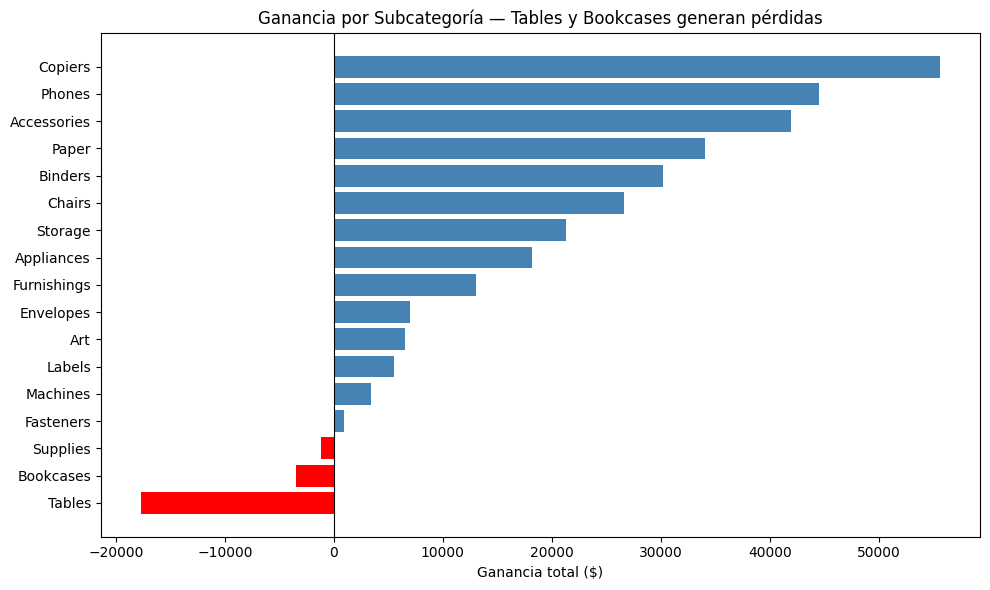

In [13]:
import matplotlib.pyplot as plt

profit_by_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10,6))
colors= ['red' if x < 0 else 'steelblue' for x in profit_by_subcat]
plt.barh(profit_by_subcat.index, profit_by_subcat.values, color=colors)
plt.title('Ganancia por Subcategoría — Tables y Bookcases generan pérdidas')
plt.xlabel('Ganancia total ($)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# ANÁLISIS DE VENTAS Y GANANCIAS A LO LARGO DEL TIEMPO

In [14]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [15]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


### Vemos una estacionalidad en las ventas en los meses de noviembre y diciembre. 

## Tendencia de Ventas a través del tiempo (año + mes)

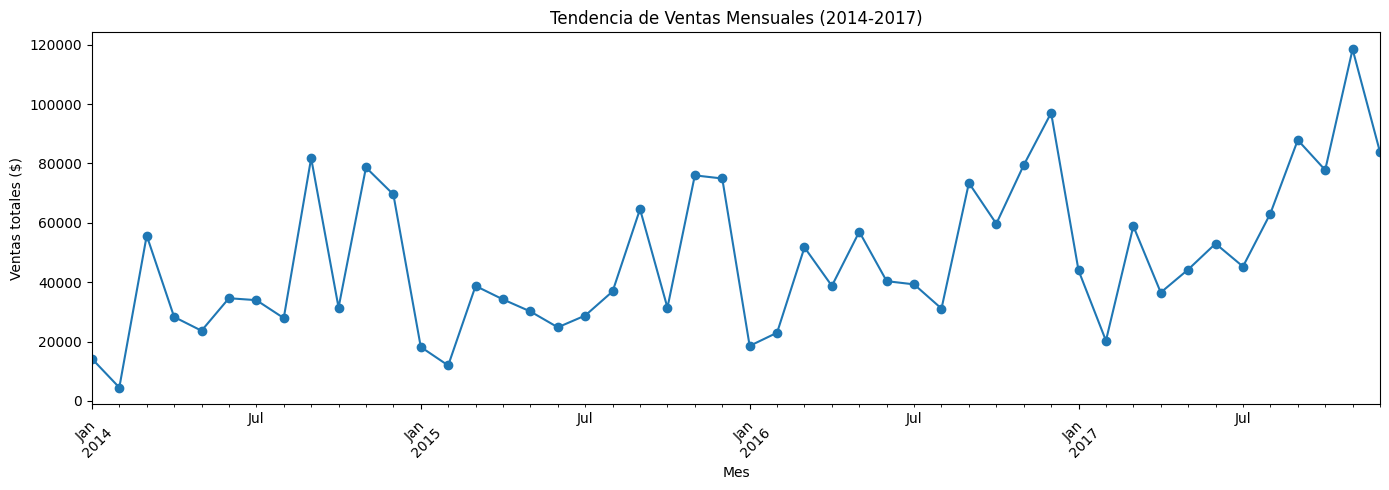

In [16]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
trend = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14,5))
trend.plot(kind='line', marker='o')
plt.title('Tendencia de Ventas Mensuales (2014-2017)')
plt.xlabel('Mes')
plt.ylabel('Ventas totales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## OBSERVACIONES

>Las ventas muestran una clara estacionalidad, con noviembre y diciembre generando más del doble de ventas que enero y febrero, consistente con patrones de compra navideña. Además, se observa una tendencia de crecimiento año con año, con los picos de venta de 2017 casi duplicando los de 2014. Se recomienda reforzar inventario y personal en Q4, y planear promociones estratégicas para Q1 que ayuden a suavizar la caída post-navideña.

# ANÁLISIS DE CLIENTES
## ¿Un grupo pequeño de clientes genera la mayoría de la ganancia?

In [17]:
profit_by_customer = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)
print(profit_by_customer.head(10))
print(f"\nTotal de clientes: {profit_by_customer.count()}")

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

Total de clientes: 793


### OBSERVACIONES

- **793** Clientes únicos
- *Tamara Chand* es la clienta más rentable (\\$8,981)

In [18]:
profit_positive = profit_by_customer[profit_by_customer > 0]  # solo clientes que SÍ generan ganancia
cumulative_pct = profit_positive.cumsum() / profit_positive.sum() * 100

print(cumulative_pct.head(20))

Customer Name
Tamara Chand             2.511405
Raymond Buch             4.462097
Sanjit Chand             6.072015
Hunter Lopez             7.644188
Adrian Barton            9.166693
Tom Ashbrook            10.481991
Christopher Martinez    11.572499
Keith Dawkins           12.422176
Andy Reiter             13.228788
Daniel Raglin           14.031055
Tom Boeckenhauer        14.813549
Nathan Mautz            15.582990
Sanjit Engle            16.324186
Bill Shonely            17.055704
Harry Marie             17.737425
Todd Sumrall            18.400617
Brian Moss              19.015590
Christopher Conant      19.624348
Jane Waco               20.232172
Helen Wasserman         20.837326
Name: Profit, dtype: float64


In [19]:
clientes_para_80pct = (cumulative_pct <= 80).sum()
total_clientes = len(profit_positive)
print(f"{clientes_para_80pct} clientes de {total_clientes} generan el 80% de la ganancia")
print(f"Eso es el {clientes_para_80pct/total_clientes*100:.1f}% de tus clientes")

255 clientes de 638 generan el 80% de la ganancia
Eso es el 40.0% de tus clientes


### OBSERVACIONES

- 255 de 638 clientes rentables (40%) generan el 80% de la ganancia. Menos de la mitad de tus clientes rentables producen la gran mayoría del dinero.
- De los 793 clientes totales, solo 638 generan ganancia positiva. Eso significa que 155 clientes (~19.5%) le generan pérdidas a la tienda.

>La ganancia está moderadamente concentrada: el 40% de los clientes rentables (255 de 638) generan el 80% de la ganancia total. Sin embargo, un hallazgo más urgente es que 155 de los 793 clientes (19.5%) generan pérdidas netas para el negocio. Se recomienda priorizar programas de retención para el segmento de alta rentabilidad, y analizar por qué ciertos clientes generan pérdidas consistentes — posiblemente vinculado a productos con descuentos excesivos como Tables.

## GRÁFICA, CURVA DE PARETO

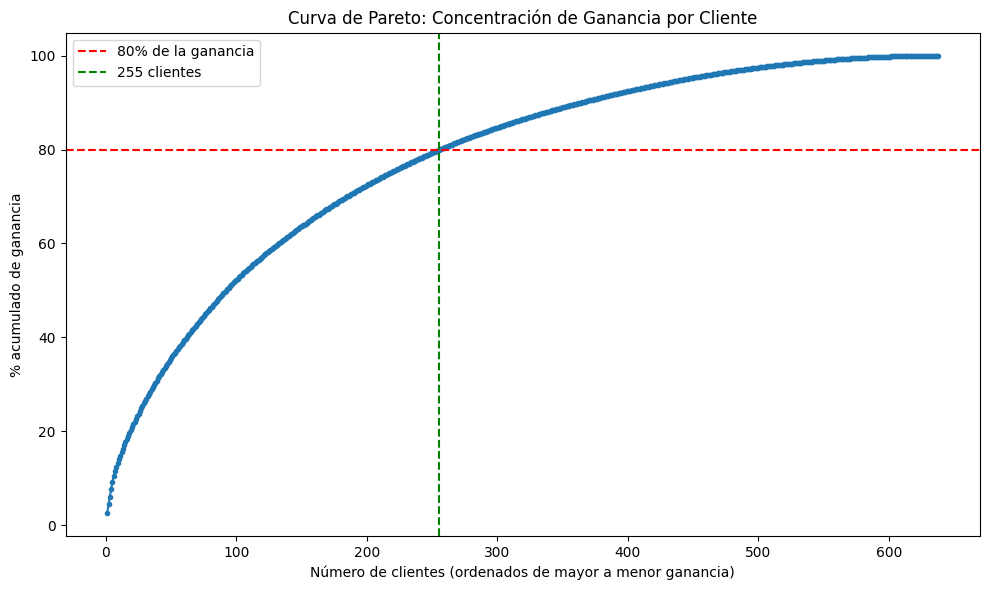

In [20]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_pct)+1), cumulative_pct.values, marker='.', linestyle='-')
plt.axhline(80, color='red', linestyle='--', label='80% de la ganancia')
plt.axvline(clientes_para_80pct, color='green', linestyle='--', label=f'{clientes_para_80pct} clientes')
plt.title('Curva de Pareto: Concentración de Ganancia por Cliente')
plt.xlabel('Número de clientes (ordenados de mayor a menor ganancia)')
plt.ylabel('% acumulado de ganancia')
plt.legend()
plt.tight_layout()
plt.show()

# CONCLUSIONES FINALES

- Furniture genera ventas similares a Office Supplies pero mucha menor ganancia, posiblemente por descuentos excesivos.
  
- Furniture sí tiene el descuento promedio más alto, 17.4% vs 13.2% de Technology, pero es una diferencia moderada, no gigante.

  
- "Tables" genera \\$206,965 en ventas pero pierde \\$17,725 — es la subcategoría menos rentable por mucho margen. Su descuento promedio (26.1%) es de los más altos.

  
- "Binders" — tiene el descuento promedio más alto de todos (37.2%) pero aun así genera una ganancia sólida de \\$30,221. Esto significa que el descuento por sí solo no es lo que mata la rentabilidad.

  
- Se ve un patrón de crecimiento a largo plazo: los picos de cada año son más altos que los del año anterior (compara el pico de 2014 vs 2017 — casi el doble). Aunque hay mucha variación mes a mes, la tienda parece estar creciendo con el tiempo.

  
- Los meses más fuertes: Noviembre (\\$352K), Diciembre (\\$325K) y Septiembre (\\$307K).
Los meses más débiles: Enero (\\$95K) y sobre todo Febrero (\\$60K) — menos de la quinta parte de noviembre.
 Esto tiene mucho sentido de negocio: Noviembre-Diciembre coincide con Black Friday, Cyber Monday y compras navideñas. Y el patrón de "caída fuerte en enero-febrero" es clásico en retail — la gente gasta en diciembre y luego recorta gastos al inicio del año nuevo.


- 255 de 638 clientes rentables (40%) generan el 80% de la ganancia.

  
- De los 793 clientes totales, solo 638 generan ganancia positiva. Eso significa que 155 clientes (~19.5%) le generan pérdidas a la tienda.